# **Importing Files**

In [ ]:
!pip install mne

     |████████████████████████████████| 7.4 MB 5.2 MB/s 


In [ ]:
import mne
import numpy as np
import pandas as pd 

from pathlib import Path
from google.colab import drive
drive.mount ('/content/drive')
%cd /content/drive/MyDrive/datasets/BCI_Dataset/dataset

Mounted at /content/drive
/content/drive/MyDrive/datasets/BCI_Dataset/dataset


In [ ]:
subject=2

# **Main code**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 

from scipy import signal
from pathlib import Path 

In [ ]:
sum=[]; sum=0; sum=np.array(sum);
X=[]; ans=[]; shape_array=[]; y_array=[];

for path in Path("/content/drive/MyDrive/datasets/BCI_Dataset/dataset").glob("B0"+str(subject)+"??T.gdf"):
    #print(path)
    sum=sum+1; #Used for keeping recording of Number of iteraions

    def datafetch(path):
      raw=mne.io.read_raw_gdf(path,eog=['EOG:ch01','EOG:ch02','EOG:ch03'], preload = True)
      ica=mne.preprocessing.ICA()
      ica.fit(raw.filter(4,38))
      event,eventid=mne.events_from_annotations(raw)
      event_ids={'769':eventid['769'],'770':eventid['770']}
      epochs=mne.Epochs(raw,event,event_id=event_ids,tmin=-.5, tmax=1.5,preload=True)
      epochs=epochs.pick_types(eeg=True)
      
      X=epochs.get_data()
      Y=epochs.events[:,-1]==event_ids['769']
      return X,Y

    a,b=datafetch(path)
    b=pd.Series(b)

    if sum==1:
       X=a;
       y=b;
    elif sum!=1:
       X=np.concatenate((X,a))
       y=np.concatenate((y,b))

l,m,n=X.shape

In [ ]:
print('X.shape: ',X.shape)
print('y.shape: ',y.shape)

X.shape:  (400, 3, 501)
y.shape:  (400,)


In [ ]:
'''
import shutil
shutil.rmtree('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/class_769')
shutil.rmtree('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/class_770')
shutil.rmtree('/content/drive/MyDrive/STFT_images/subject_'+str(subject))
'''

"\nimport shutil\nshutil.rmtree('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/class_769')\nshutil.rmtree('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/class_770')\nshutil.rmtree('/content/drive/MyDrive/STFT_images/subject_'+str(subject))\n"

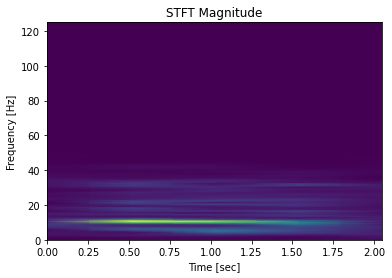

In [ ]:
#%cd /content/drive/MyDrive/STFT_images
os.mkdir('/content/drive/MyDrive/STFT_images/subject_'+str(subject))
os.mkdir('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/class_769')
os.mkdir('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/class_770')
    
reset_num=0

for i in range(l):
    if y[i]==True:
            f, t, Zxx = signal.stft(X[i,1,:],fs=250)
            plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
            plt.title('STFT Magnitude')
            plt.ylabel('Frequency [Hz]')
            plt.xlabel('Time [sec]')

            myfig= plt.plot()
            plt.savefig('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/class_769/fig'+str(i)+'.png')
    else: 
            plt.savefig('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/class_770/fig'+str(i)+'.png')

# **InceptionV3 Model:**

In [ ]:
def my_trainset():
  import glob
  import tensorflow as tf 
  import numpy as np

  #Training part:
  class_769 = glob.glob('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/class_769/*.*')
  class_770 = glob.glob('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/class_770/*.*')

  data = []
  labels = []

  for i in class_769:   
        image=tf.keras.preprocessing.image.load_img(i, color_mode='rgb', target_size= (432,288))
        image=np.array(image)
        data.append(image)
        labels.append(0)
  for i in class_770:   
        image=tf.keras.preprocessing.image.load_img(i, color_mode='rgb', target_size= (432,288))
        image=np.array(image)
        data.append(image)
        labels.append(1)
  
  data = np.array(data)
  labels = np.array(labels)

  return data,labels

In [ ]:
def my_testset():
  import glob
  import tensorflow as tf 
  import numpy as np

  class_769 = glob.glob('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/class_769/*.*')
  class_770 = glob.glob('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/class_770/*.*')

  data = []
  labels = []

  for i in class_769:   
      image=tf.keras.preprocessing.image.load_img(i, color_mode='rgb', target_size= (432,288))
      image=np.array(image)
      data.append(image)
      labels.append(0)
  for i in class_770:   
      image=tf.keras.preprocessing.image.load_img(i, color_mode='rgb', target_size= (432,288))
      image=np.array(image)
      data.append(image)
      labels.append(1)

  X_test = np.array(data)
  y_test = np.array(labels)
  return X_test,y_test

In [ ]:
import tensorflow.keras as K
import tensorflow as tf

from keras.callbacks import EarlyStopping
#set early stopping monitor so the model stops training when it won't improve anymore
early_stopping_monitor = EarlyStopping(patience=8)

In [ ]:
def preprocess_data(X, Y):
    """
    a function that trains a convolutional neural network to classify the
    CIFAR 10 dataset
    :param X: X is a numpy.ndarray of shape (m, 32, 32, 3) containing the
    CIFAR 10 data, where m is the number of data points
    :param Y: Y is a numpy.ndarray of shape (m,) containing the CIFAR 10
    labels for X
    :return: X_p, Y_p
        X_p is a numpy.ndarray containing the preprocessed X
        Y_p is a numpy.ndarray containing the preprocessed Y
    """
    X_p = K.applications.inception_v3.preprocess_input(X)
    Y_p = K.utils.to_categorical(Y)
    return X_p, Y_p

data,labels=my_trainset()
from sklearn.model_selection import train_test_split
x_train, x_validation, y_train, y_validation = train_test_split(data, labels, test_size=0.2,random_state=42)


print((x_train.shape, y_train.shape))
x_train, y_train = preprocess_data(x_train, y_train)
x_validation, y_validation = preprocess_data(x_validation, y_validation)
print((x_train.shape, y_train.shape))

((395, 432, 288, 3), (395,))
((395, 432, 288, 3), (395, 2))


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import models
from tensorflow.keras import layers 

conv_base = InceptionV3(weights='imagenet', include_top=False,input_shape=(432, 288, 3)) 
conv_base.trainable = False

model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(2, activation='sigmoid'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

87924736/87910968 [==============================] - 1s 0us/step


In [ ]:
#history=model.fit(x_train, y_train, validation_data=(x_validation, y_validation), callbacks=[early_stopping_monitor], epochs=30) 
history=model.fit(x_train, y_train, validation_data=(x_validation, y_validation),epochs=40)

In [ ]:
X_test,y_test=my_testset()

X_test = K.applications.inception_v3.preprocess_input(X_test)
y_test = K.utils.to_categorical(y_test)

In [ ]:
test_loss, test_acc = model.evaluate(X_test,y_test)

16/16 [==============================] - 8s 530ms/step - loss: 0.6961 - accuracy: 0.7308


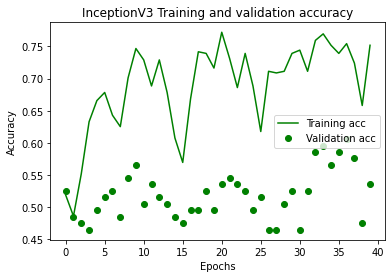

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc,color='green',linestyle='-' , label='Training acc')
plt.plot(epochs, val_acc,'go', label='Validation acc')
plt.title('InceptionV3 Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/Training VS Val Acc.png')
plt.show()

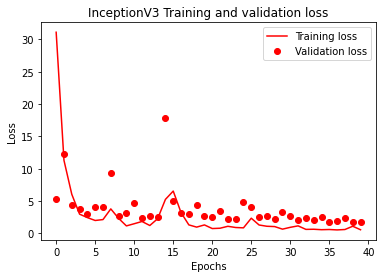

In [ ]:
plt.plot(epochs, loss, color='red',linestyle='-', label='Training loss')
plt.plot(epochs, val_loss, 'ro', label='Validation loss')
plt.title('InceptionV3 Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig('/content/drive/MyDrive/STFT_images/subject_'+str(subject)+'/Training VS Val Loss.png')
plt.show()